In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm

In [2]:
X = np.load('datasets/dataset1/X.npy')
y = np.load('datasets/dataset1/y.npy')

In [3]:
def plot_data(X, y):
    """
    Plots the data points X and y into a new figure.
    - X: 2D array where each row is a data point (assumed to have 2 features).
    - y: 1D array of labels (0 or 1).

    Plots:
    - '+' for positive examples (y = 1)
    - 'o' for negative examples (y = 0)
    """

    # Find indices of positive and negative examples
    pos = np.where(y == 1)[0]  # Indices where y = 1
    neg = np.where(y == 0)[0]  # Indices where y = 0

    # Create plot
    plt.figure(figsize=(8, 6))

    # Plot positive examples as black '+'
    plt.scatter(X[pos, 0], X[pos, 1], marker='+', c='k', s=70, linewidths=1)

    # Plot negative examples as yellow 'o' (filled)
    plt.scatter(X[neg, 0], X[neg, 1], marker='o', c='y', edgecolors='k', s=70)

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(['Positive (y=1)', 'Negative (y=0)'], loc='upper right')
    plt.grid(True)
    plt.show()

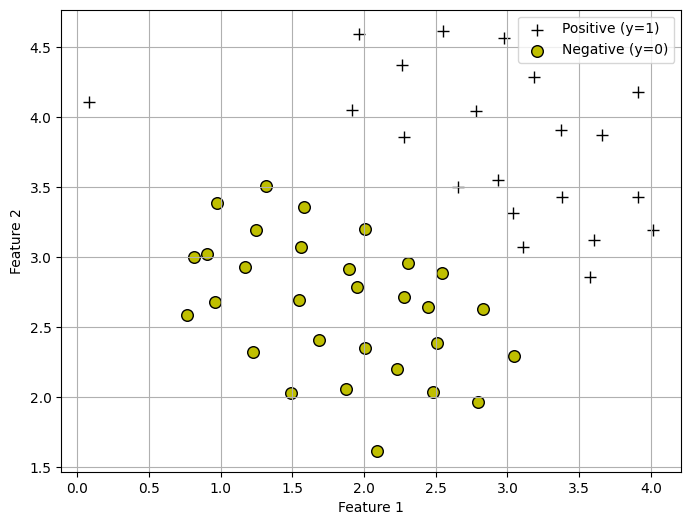

In [4]:
plot_data(X,y)

In [16]:
# << linear kernel is enough here >>

# EXO1 : 

In [24]:
svc = svm.SVC

model = svc(kernel='linear', C=1.0) # **linear decision boundary !**
model.fit(X, y)

print(f"Training accuracy: {model.score(X, y) * 100:.2f}%")

Training accuracy: 98.04%


In [9]:
def visualize_boundary(X, y, model, title="test"):
    """
    Plots the decision boundary of an SVM model.
    - X: 2D array of training data (n_samples, 2 features).
    - y: 1D array of labels (0 or 1).
    - model: Trained SVM classifier (from sklearn.svm.SVC).
    """
    # Create a grid of points spanning the feature space
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))

    # Predict SVM labels for each grid point
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary and margins
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.2,
                 colors=['yellow', 'cyan', 'yellow'])  # Filled contours
    plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')  # Boundary

    # Plot training data (same as plot_data() earlier)
    pos = np.where(y == 1)[0]
    neg = np.where(y == 0)[0]
    plt.scatter(X[pos, 0], X[pos, 1], marker='+', c='k', s=70, label='Positive')
    plt.scatter(X[neg, 0], X[neg, 1], marker='o', c='y', edgecolors='k', s=70, label='Negative')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

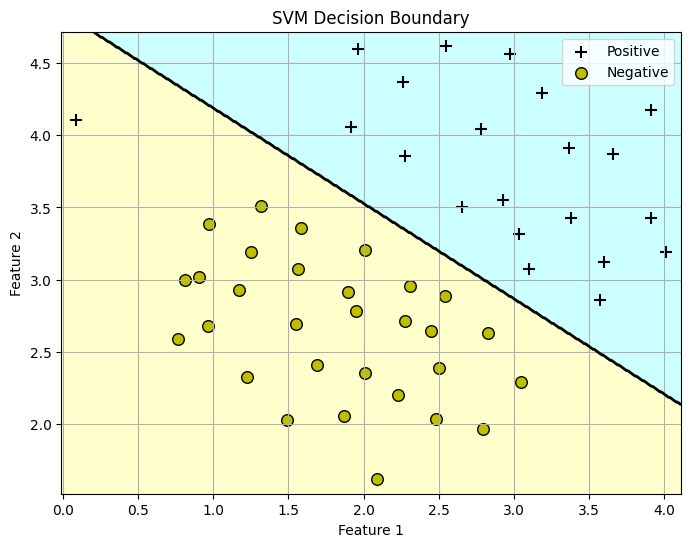

In [10]:
visualize_boundary(X,y,model,'SVM Decision Boundary')

C = 0.1   | Training accuracy = 98.04%


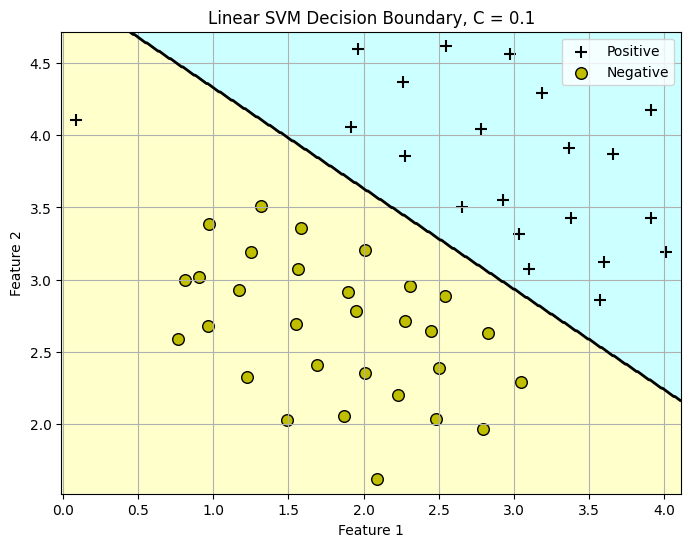

C = 1.0   | Training accuracy = 98.04%


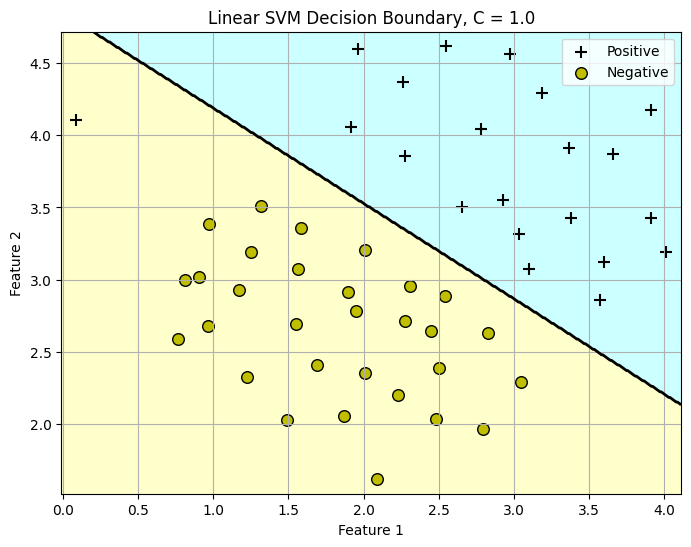

C = 10    | Training accuracy = 98.04%


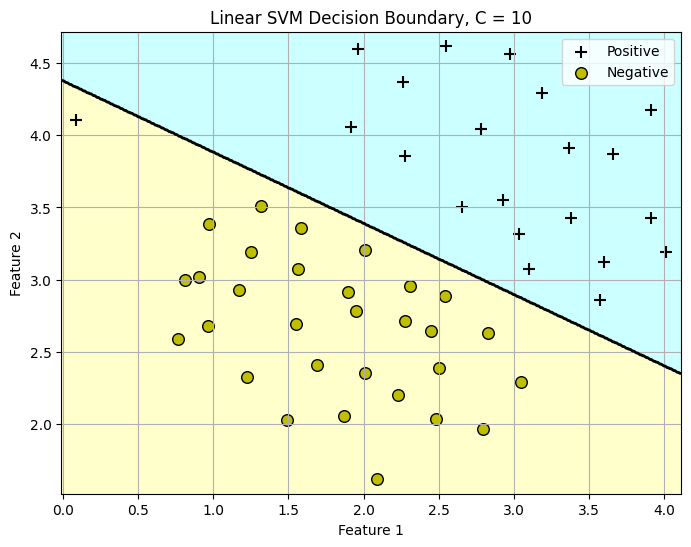

C = 100   | Training accuracy = 100.00%


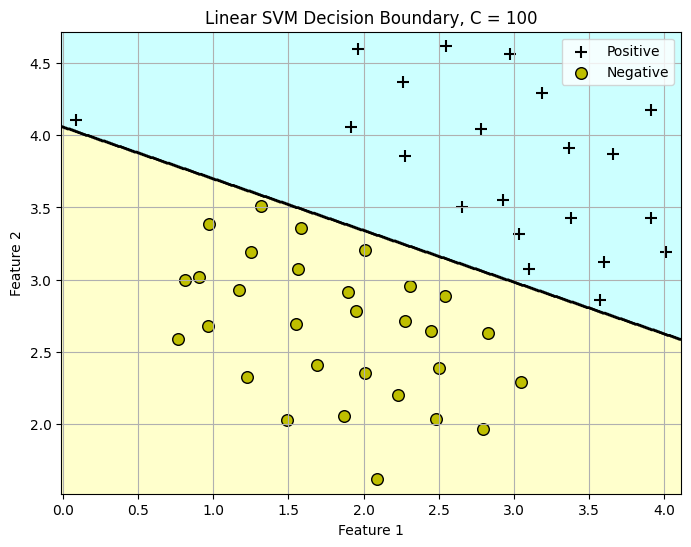

In [14]:
C_values = [0.1, 1.0, 10, 100]

# START CODE HERE

for C in C_values:
    model_C = svm.SVC(kernel='linear', C=C)
    model_C.fit(X, y.ravel())

    train_accuracy = model_C.score(X, y)
    print(f"C = {C:<5} | Training accuracy = {train_accuracy * 100:.2f}%")

    visualize_boundary(
        X, 
        y, 
        model_C, 
        title=f"Linear SVM Decision Boundary, C = {C}"
    )

# END CODE HERE

# EXO3 : RBF kernel 🚀🚀

In [25]:
# CODE STARTS HERE

sigma = 0.1
gamma = 1 / (2 * sigma**2)

model_rbf = svm.SVC(kernel='rbf', C=1.0, gamma=gamma)
model_rbf.fit(X, y.ravel())

print(f"sigma = {sigma}")
print(f"gamma = {gamma}")
print(f"Training accuracy: {model_rbf.score(X, y):.4f}")

# CODE ENDS HERE

sigma = 0.1
gamma = 49.99999999999999
Training accuracy: 1.0000


In [26]:
def visualize_nonLin_boundary(X, y, model, title = 'test'):
    plt.figure(figsize=(8, 6))

    # Plot training data
    pos = np.where(y == 1)[0]
    neg = np.where(y == 0)[0]
    plt.scatter(X[pos, 0], X[pos, 1], marker='+', c='k', s=70, label='Positive')
    plt.scatter(X[neg, 0], X[neg, 1], marker='o', c='y', edgecolors='k', s=70, label='Negative')

    # Create grid for contour plot
    x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
    y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Predict probabilities across grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary (contour at Z=0) and margins (contours at Z=-1 and Z=1)
    plt.contour(xx, yy, Z, levels=[-1, 0, 1],
                colors=['gray', 'black', 'gray'],
                linestyles=['--', '-', '--'], linewidths=[1, 2, 1])

    # Fill decision regions
    plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 10),
                alpha=0.1, cmap='coolwarm')

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('SVM Decision Boundary with Contours')
    plt.legend()
    plt.grid(True)
    plt.show()

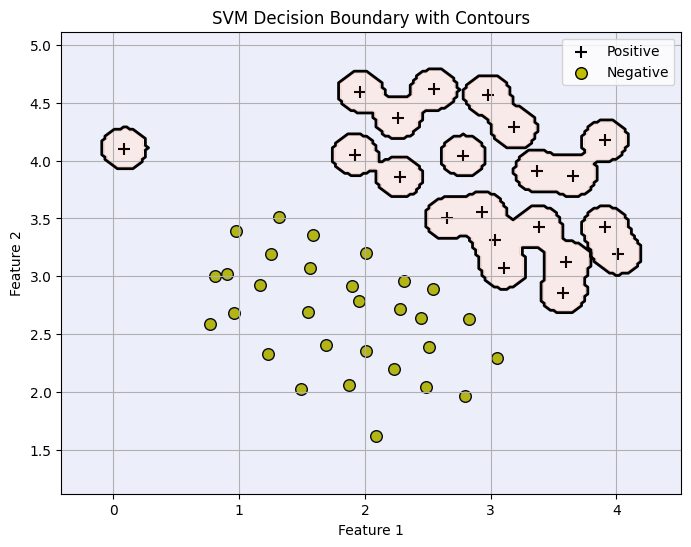

In [27]:
visualize_nonLin_boundary(X, y, model_rbf,'SVM Decision Boundary with Contours')

# EXO4 : 

In [28]:
X = np.load("datasets/dataset3/X.npy")
y = np.load("datasets/dataset3/y.npy")
Xval = np.load("datasets/dataset3/Xval.npy")
yval = np.load("datasets/dataset3/yval.npy")

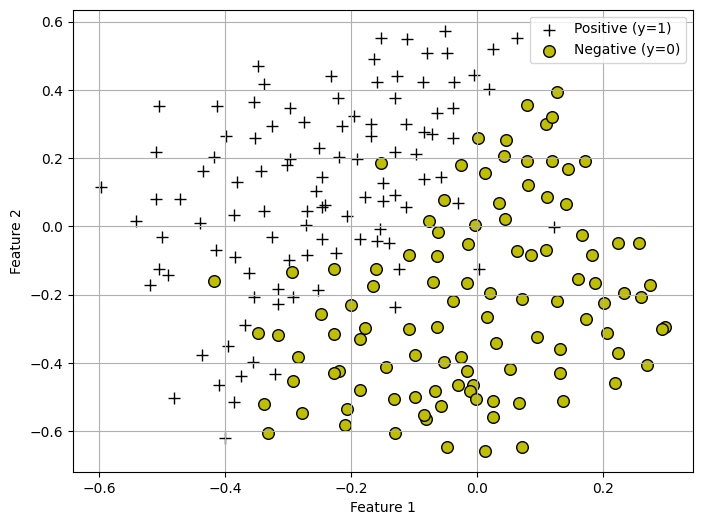

In [29]:
plot_data(X,y)

In [31]:
# CODE STARTS HERE

C_values = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30]
sigma_values = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30]

best_C = None
best_sigma = None
best_error = float("inf")

for C in C_values:
    for sigma in sigma_values:
        
        gamma = 1 / (2 * sigma**2)
        
        model = svm.SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(X, y.ravel())
        
        predictions = model.predict(Xval)
        error = np.mean(predictions != yval.ravel())
        
        if error < best_error:
            best_error = error
            best_C = C
            best_sigma = sigma

print(f"Best C: {best_C}")
print(f"Best sigma: {best_sigma}")
print(f"Validation error: {best_error:.4f}")

# CODE ENDS HERE

Best C: 1
Best sigma: 0.1
Validation error: 0.0350


# EXO5 :

In [32]:
# CODE STARTS HERE

gamma = 1 / (2 * best_sigma**2)

best_model = svm.SVC(kernel='rbf', C=best_C, gamma=gamma)
best_model.fit(X, y.ravel())

print(f"Training accuracy: {best_model.score(X, y.ravel()):.4f}")
print(f"Validation accuracy: {best_model.score(Xval, yval.ravel()):.4f}")

# CODE ENDS HERE

Training accuracy: 0.9479
Validation accuracy: 0.9650
